# Case Study: Advanced Analysis of Backpropagation

This portfolio notebook develops a reproducible neural-network workflow for an ordinal wine-quality target. It covers exploratory analysis, leakage-safe preprocessing, layer-wise gradient diagnostics, controlled optimisation experiments, regularisation, model selection, and a single final test-set evaluation.


In [92]:
# Part 0: Environment Setup

from copy import deepcopy
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
import json
import platform
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as exc:
    raise ImportError(
        "TensorFlow is required. Install it with: "
        "python -m pip install tensorflow numpy pandas matplotlib seaborn scikit-learn"
    ) from exc

SEED = 42
MAX_EPOCHS = 40
BATCH_SIZE = 32
PATIENCE = 7

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

set_all_seeds()
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

print({
    "python": platform.python_version(),
    "tensorflow": tf.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
})


{'python': '3.13.15', 'tensorflow': '2.20.0', 'numpy': '2.1.3', 'pandas': '2.2.3'}


# Part 1: Data Preparation & Feature Engineering


### This section
1. Loads the Wine Quality dataset (`winequality-red.csv` or equivalent).  
2. Performs statistical analysis of features.  
3. Engineers a few new features  
4. Applies preprocessing: scaling, encoding and feature selection.  
5. Creates stratified train/val/test splits.  


In [93]:
LOCAL_DATA_PATH = Path("data/winequality-red.csv")
UCI_ARCHIVE_URL = "https://archive.ics.uci.edu/static/public/186/wine+quality.zip"

if LOCAL_DATA_PATH.exists():
    wine = pd.read_csv(LOCAL_DATA_PATH, sep=";")
    data_source = str(LOCAL_DATA_PATH)
else:
    with urlopen(UCI_ARCHIVE_URL, timeout=60) as response:
        archive_bytes = response.read()
    with ZipFile(BytesIO(archive_bytes)) as archive:
        with archive.open("winequality-red.csv") as csv_file:
            wine = pd.read_csv(csv_file, sep=";")
    data_source = UCI_ARCHIVE_URL

print(f"Loaded {wine.shape[0]:,} rows and {wine.shape[1]} columns from {data_source}")
wine.head()


Loaded 1,599 rows and 12 columns from https://archive.ics.uci.edu/static/public/186/wine+quality.zip


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [10]:
wine.shape

(1599, 12)

In [13]:
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [11]:
EXPECTED_COLUMNS = {
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol", "quality",
}

assert set(wine.columns) == EXPECTED_COLUMNS, "Unexpected columns"
assert not wine.isna().any().any(), "Missing values require an explicit treatment"
assert wine["quality"].between(0, 10).all(), "Quality is outside the documented scale"

data_quality_summary = pd.Series({
    "rows": len(wine),
    "predictors": wine.shape[1] - 1,
    "missing_cells": int(wine.isna().sum().sum()),
    "exact_duplicate_rows": int(wine.duplicated().sum()),
    "quality_min": int(wine["quality"].min()),
    "quality_max": int(wine["quality"].max()),
}, name="value")
data_quality_summary.to_frame()

,value
rows,1599
predictors,11
missing_cells,0
exact_duplicate_rows,240
quality_min,3
quality_max,8


#EDA and Feature Engineering

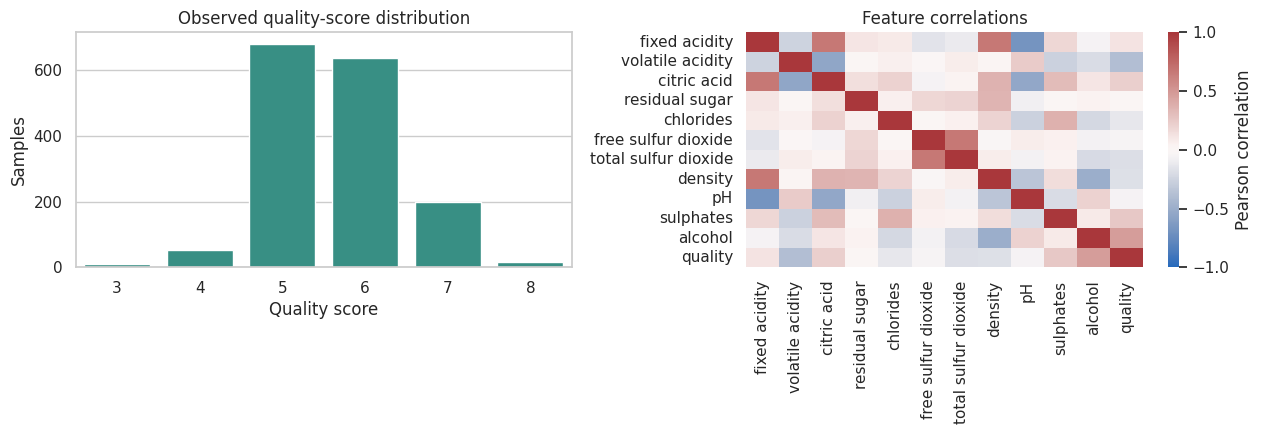

,correlation_with_quality
alcohol,0.476166
volatile acidity,-0.390558
sulphates,0.251397
citric acid,0.226373
total sulfur dioxide,-0.185100
density,-0.174919


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

quality_counts = wine["quality"].value_counts().sort_index()
sns.barplot(x=quality_counts.index, y=quality_counts.values, color="#2a9d8f", ax=axes[0])
axes[0].set(title="Observed quality-score distribution", xlabel="Quality score", ylabel="Samples")

correlations = wine.corr(numeric_only=True)
sns.heatmap(
    correlations,
    cmap="vlag", center=0, vmin=-1, vmax=1,
    square=False, cbar_kws={"label": "Pearson correlation"}, ax=axes[1]
)
axes[1].set_title("Feature correlations")
plt.tight_layout()
plt.show()

quality_correlations = (
    correlations["quality"].drop("quality").sort_values(key=np.abs, ascending=False)
)
display(quality_correlations.rename("correlation_with_quality").to_frame().head(6))
display(wine.describe().T.round(3))

From the correlation heatmap, it can be noticed that red wine quality has negative correlation with volatile acidity and positive correlation with alcohol.

The target is concentrated in the middle scores, with few very low- or high-quality observations. This is why the split is stratified. Alcohol, volatile acidity, and sulphates usually show the strongest linear associations with quality in this sample, but these correlations may reflect confounding, measurement design, or the composition of the sampled wines.

In [15]:
wine.quality.unique()

array([5, 6, 7, 4, 8, 3])

In [16]:
wine.quality.value_counts(normalize=True)

,proportion
quality,
5,0.425891
6,0.398999
7,0.124453
4,0.033146
8,0.011257
3,0.006254


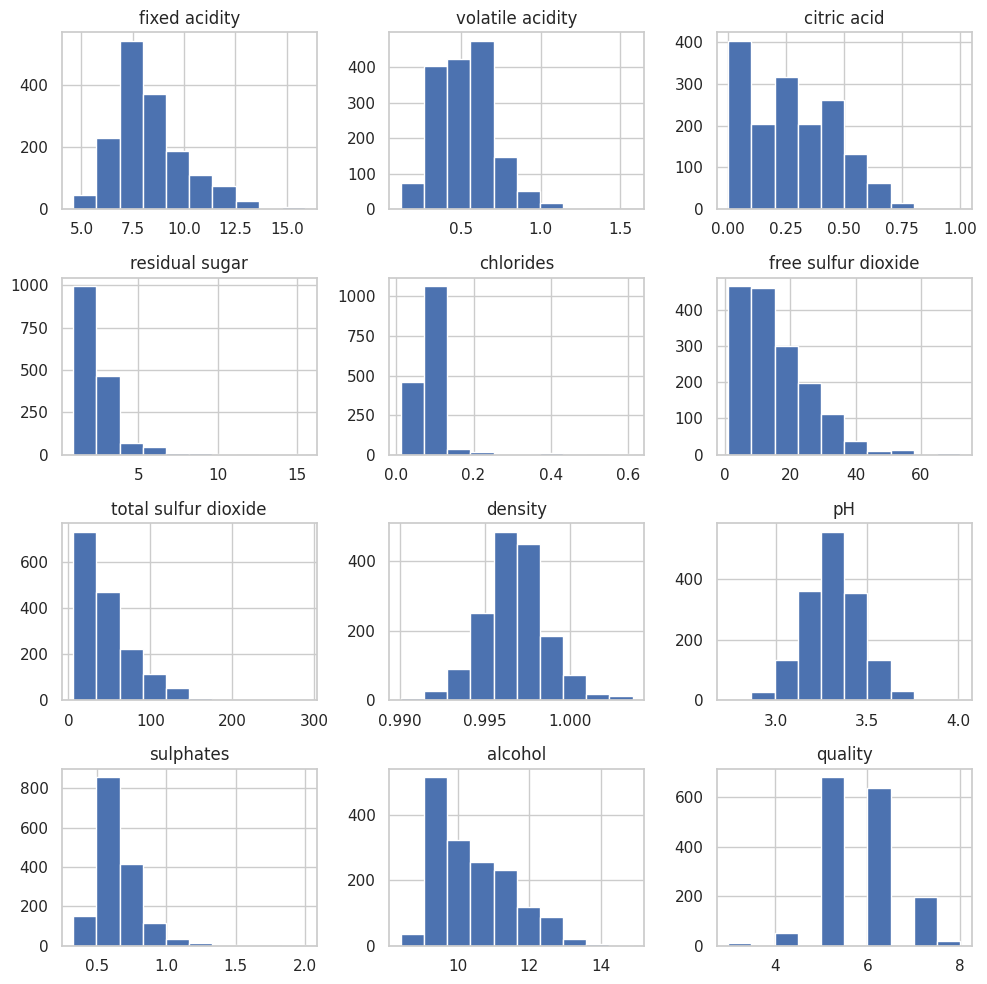

In [17]:
wine.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

The histograms show skewed distributions except for density and pH.

##Feature engineering

The first ratio is alcohol and density. If the ratio increases it can be indicator of good fermentation process. The second ratio is the volatile acidity ratio. If the ratio increases means that the wine can smell like vinegar. The last variable is the total acidity of the wine.

Sources: https://extension.psu.edu/volatile-acidity-in-wine
https://bibinmjose.github.io/RedWineDataAnalysis/

In [22]:
def engineer_features(frame):
    engineered = frame.copy()
    epsilon = 1e-6
    engineered["alcohol_density_ratio"] = engineered["alcohol"] / (engineered["density"] + epsilon)
    engineered["volatile_fixed_acidity_ratio"] = (
        engineered["volatile acidity"] / (engineered["fixed acidity"] + epsilon)
    )
    engineered["free_total_so2_ratio"] = (
        engineered["free sulfur dioxide"] /
        (engineered["total sulfur dioxide"] + epsilon)
    )
    return engineered

model_data = engineer_features(wine)
X = model_data.drop(columns="quality")
y = model_data["quality"]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.40, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.50, random_state=SEED, stratify=y_holdout
)

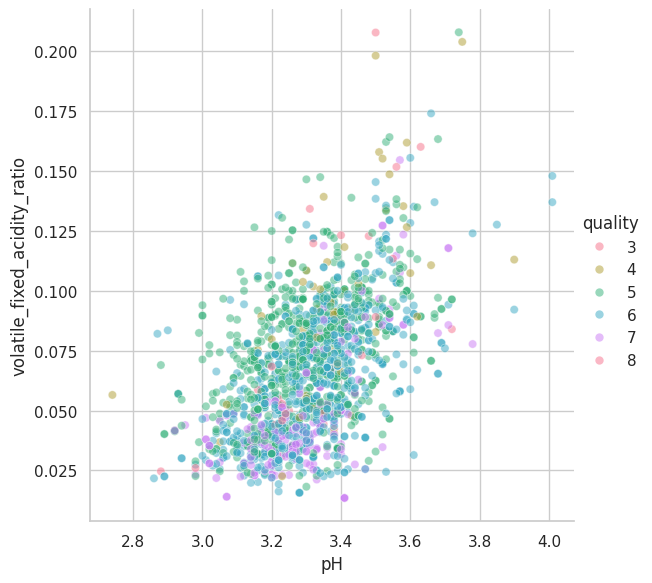

In [23]:
sns.relplot(data=model_data, x="pH", y="volatile_fixed_acidity_ratio", hue='quality', kind='scatter',
            sizes=(40, 400), alpha=.5, palette="husl",
            height=6)

In [24]:
model_data = engineer_features(wine)
X = model_data.drop(columns="quality")
y = model_data["quality"]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.40, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_holdout, y_holdout, test_size=0.50, random_state=SEED, stratify=y_holdout
)

k_values = [6, 8, 10, 12, 14]
feature_selection_results = []

for k in k_values:
    selector = SelectKBest(score_func=f_regression, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_val_selected = selector.transform(X_val)
    X_test_selected = selector.transform(X_test)
    selected_feature_names = X_train.columns[selector.get_support()].tolist()


scaler = StandardScaler()
X_train_scaled_k = scaler.fit_transform(X_train_selected).astype("float32")
X_val_scaled_k = scaler.transform(X_val_selected).astype("float32")
X_test_scaled = scaler.transform(X_test_selected).astype("float32")

y_train_array = y_train.to_numpy(dtype="float32").reshape(-1, 1)
y_val_array = y_val.to_numpy(dtype="float32").reshape(-1, 1)
y_test_array = y_test.to_numpy(dtype="float32").reshape(-1, 1)

tf.keras.backend.clear_session()
set_all_seeds(SEED)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "share": [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
    "mean_quality": [y_train.mean(), y_val.mean(), y_test.mean()],
}, index=["train", "validation", "test"])

assert X_train_scaled_k.shape[1] == X_val_scaled_k.shape[1] == X_test_scaled.shape[1]
assert y_train_array.shape == (len(X_train), 1)
display(split_summary.style.format({"share": "{:.1%}", "mean_quality": "{:.3f}"}))
display(pd.DataFrame({
    "feature": X_train.columns,
    "f_score": selector.scores_,
    "selected": selector.get_support(),
}).sort_values("f_score", ascending=False).style.format({"f_score": "{:.2f}"}))


,rows,share,mean_quality
train,959,60.0%,5.636
validation,320,20.0%,5.641
test,320,20.0%,5.631


,feature,f_score,selected
10,alcohol,280.78,True
11,alcohol_density_ratio,279.37,True
1,volatile acidity,163.55,True
12,volatile_fixed_acidity_ratio,126.24,True
13,free_total_so2_ratio,48.91,True
9,sulphates,46.54,True
6,total sulfur dioxide,43.05,True
2,citric acid,42.58,True
7,density,35.23,True
4,chlorides,19.90,True


In [25]:
# Validation baseline: always predict the training-set mean.
validation_baseline_prediction = np.full_like(y_val_array, y_train_array.mean())
validation_baseline = pd.Series({
    "MAE": mean_absolute_error(y_val_array, validation_baseline_prediction),
    "RMSE": mean_squared_error(y_val_array, validation_baseline_prediction) ** 0.5,
}, name="mean baseline")
validation_baseline.to_frame().T.style.format("{:.4f}")

,MAE,RMSE
mean baseline,0.6844,0.8095


In [27]:
tf.keras.backend.clear_session()
set_all_seeds(SEED)

In [45]:
def build_model(input_dim, depth=3, units=64):

    model = keras.Sequential()

    model.add(
        layers.Input(shape=(input_dim,))
    )

    for _ in range(depth):
        model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

    model.add(layers.Dense(1))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

model = build_model(
    input_dim=X_train_scaled_k.shape[1],
    depth=3,
    units=64
)

early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    )

history = model.fit(X_train_scaled_k,y_train_array,validation_data=(X_val_scaled_k,y_val_array
        ),
        epochs=40,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

val_loss, val_mae = model.evaluate(
        X_val_scaled_k,
        y_val_array,
        verbose=0
    )

feature_selection_results.append({
        "k": k,
        "validation_loss": val_loss,
        "validation_mae": val_mae,
        "selected_features": selected_feature_names
    })

In [59]:
feature_selection_results_df = pd.DataFrame(
    feature_selection_results
)

feature_selection_results_df[
    ["k", "validation_loss", "validation_mae"]
].sort_values("validation_mae")

,k,validation_loss,validation_mae
0,14,0.464951,0.515820
1,14,0.516602,0.545301


In [69]:
best_result = min(
    feature_selection_results,
    key=lambda result: result["validation_mae"]
)

best_k = best_result["k"]
best_feature_names = best_result["selected_features"]

print("Best number of features:", best_k)
print("Selected features:", best_feature_names)
print("Validation MAE:", best_result["validation_mae"])

Best number of features: 14
Selected features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'alcohol_density_ratio', 'volatile_fixed_acidity_ratio', 'free_total_so2_ratio']
Validation MAE: 0.5158202052116394


In [70]:
best_selector = SelectKBest(
    score_func=f_regression,
    k=best_k
)

X_train_selected_kbest = best_selector.fit_transform(
    X_train,
    y_train
)

X_val_selected_kbest = best_selector.transform(X_val)
X_test_selected_kbest = best_selector.transform(X_test)

In [71]:
best_scaler = StandardScaler()

X_train_scaled_best = best_scaler.fit_transform(X_train_selected_kbest).astype("float32")

X_val_scaled_best = best_scaler.transform(X_val_selected_kbest).astype("float32")

X_test_scaled_best = best_scaler.transform(X_test_selected_kbest).astype("float32")

# Part 2: Gradient Flow Analysis


In [51]:
LEARNING_RATES = {"sgd": 1e-2, "adam": 1e-3, "rmsprop": 1e-3, "adagrad": 1e-2}

def make_regularizer(kind=None, l1=1e-5, l2=1e-4):
    if kind is None:
        return None
    if kind == "l1":
        return keras.regularizers.l1(l1)
    if kind == "l2":
        return keras.regularizers.l2(l2)
    if kind == "elastic_net":
        return keras.regularizers.l1_l2(l1=l1, l2=l2)
    raise ValueError(f"Unknown regularizer: {kind}")

def make_optimizer(name="adam", use_schedule=False, clipnorm=None):
    name = name.lower()
    initial_lr = LEARNING_RATES[name]
    learning_rate = (
        keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=initial_lr,
            decay_steps=100,
            decay_rate=0.96,
            staircase=True,
        )
        if use_schedule else initial_lr
    )
    classes = {
        "sgd": keras.optimizers.SGD,
        "adam": keras.optimizers.Adam,
        "rmsprop": keras.optimizers.RMSprop,
        "adagrad": keras.optimizers.Adagrad,
    }
    return classes[name](learning_rate=learning_rate, clipnorm=clipnorm)

def build_model(config, input_dim):
    regularizer = make_regularizer(
        config.get("regularizer"),
        l1=config.get("l1", 1e-5),
        l2=config.get("l2", 1e-4),
    )
    model1 = keras.Sequential(name=config.get("name", "wine_quality_mlp"))
    model1.add(layers.Input(shape=(input_dim,), name="features"))

    for layer_index in range(config.get("depth", 3)):
        model1.add(layers.Dense(
            config.get("units", 64),
            kernel_initializer=config.get("initializer", "he_uniform"),
            kernel_regularizer=regularizer,
            use_bias=not config.get("batch_norm", False),
            name=f"hidden_{layer_index + 1}",
        ))
        activation = config.get("activation", "relu")
        if activation == "leaky_relu":
            model1.add(layers.LeakyReLU(negative_slope=0.01, name=f"leaky_relu_{layer_index + 1}"))
        else:
            model1.add(layers.Activation(activation, name=f"{activation}_{layer_index + 1}"))
        if config.get("batch_norm", False):
            model1.add(layers.BatchNormalization(name=f"batch_norm_{layer_index + 1}"))
        if config.get("dropout", 0.0) > 0:
            model1.add(layers.Dropout(config["dropout"], name=f"dropout_{layer_index + 1}"))

    model1.add(layers.Dense(1, name="quality_score"))
    model1.compile(
        optimizer=make_optimizer(
            config.get("optimizer", "adam"),
            use_schedule=config.get("lr_schedule", False),
            clipnorm=config.get("clipnorm"),
        ),
        loss="mse",
        metrics=["mae"],
    )
    return model1

In [60]:
y_train_array = (
    y_train
    .to_numpy(dtype="float32")
    .reshape(-1, 1)
)

y_val_array = (
    y_val
    .to_numpy(dtype="float32")
    .reshape(-1, 1)
)

In [61]:
model_config = {
    "name": "selected_feature_model",
    "depth": 3,
    "units": 64,
    "activation": "relu",
    "initializer": "he_uniform",
    "optimizer": "adam",
    "batch_norm": False,
    "lr_schedule": False,
    "regularizer": None,
    "dropout": 0.0,
    "clipnorm": 1.0,
}

In [62]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

In [72]:
model1 = build_model(
    config=model_config,
    input_dim=X_train_scaled_best.shape[1]
)

In [73]:
model1.summary()

Model: "selected_feature_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ quality_score (Dense)           │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,345 (36.50 KB)

 Trainable params: 9,345 (36.50 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

In [75]:
history1 = model1.fit(
    X_train_scaled_best,
    y_train_array,
    validation_data=(
        X_val_scaled_best,
        y_val_array
    ),
    epochs=40,
    batch_size=32,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=1
)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 4.7994 - mae: 1.6983 - val_loss: 2.3654 - val_mae: 1.2433
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 2.2549 - mae: 1.1638 - val_loss: 1.8341 - val_mae: 1.0995
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.7488 - mae: 1.0291 - val_loss: 1.5944 - val_mae: 1.0204
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.4341 - mae: 0.9293 - val_loss: 1.4262 - val_mae: 0.9565
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.1898 - mae: 0.8418 - val_loss: 1.3072 - val_mae: 0.9075
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0051 - mae: 0.7690 - val_loss: 1.2065 - val_mae: 0.8654
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8571 - mae: 0.7063 - val_loss: 1.1361 - val_mae: 0.8303
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.7449 - mae: 0.6577 - val_loss: 1.0996 - val_mae: 0.8075
Epoch 9/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.661

In [77]:
class LayerwiseGradientLogger(keras.callbacks.Callback):
    """Record kernel-gradient magnitude for each trainable layer once per epoch."""

    def __init__(self, x_sample, y_sample):
        super().__init__()
        self.x_sample = tf.convert_to_tensor(x_sample, dtype=tf.float32)
        self.y_sample = tf.convert_to_tensor(y_sample, dtype=tf.float32)
        self.records = []

    def on_epoch_end(self, epoch, logs=None):
        with tf.GradientTape() as tape:
            prediction = self.model(self.x_sample, training=False)
            data_loss = tf.reduce_mean(tf.square(self.y_sample - prediction))
            regularization_loss = tf.add_n(self.model.losses) if self.model.losses else 0.0
            total_loss = data_loss + regularization_loss

        variables = self.model.trainable_variables
        gradients = tape.gradient(total_loss, variables)
        variable_to_layer = {
            id(variable): layer.name
            for layer in self.model.layers
            for variable in layer.trainable_variables
        }

        for variable, gradient in zip(variables, gradients):
            variable_name = getattr(variable, "path", variable.name)
            if gradient is None or "kernel" not in variable_name:
                continue
            self.records.append({
                "epoch": epoch + 1,
                "layer": variable_to_layer.get(id(variable), variable_name),
                "l2_norm": float(tf.linalg.global_norm([gradient]).numpy()),
                "mean_abs_gradient": float(tf.reduce_mean(tf.abs(gradient)).numpy()),
            })


In [78]:
gradient_records = []
depth_histories = {}
depth_validation_rows = []
gradient_x = X_train_scaled_best[:32]
gradient_y = y_train_array[:32]

for depth in [3, 6, 9, 12]:
    tf.keras.backend.clear_session()
    set_all_seeds(SEED)
    depth_config = {
        "depth": depth,
        "units": 64,
        "activation": "relu",
        "initializer": "he_uniform",
        "optimizer": "adam",
        "clipnorm": None,  # observe raw gradient behaviour
        "name": f"depth_{depth}",
    }
    gradient_logger = LayerwiseGradientLogger(gradient_x, gradient_y)
    depth_model = build_model(depth_config, X_train_scaled.shape[1])
    history = depth_model.fit(
        X_train_scaled_best,
        y_train_array,
        validation_data=(X_val_scaled_best, y_val_array),
        epochs=20,
        batch_size=BATCH_SIZE,
        callbacks=[gradient_logger],
        verbose=0,
        shuffle=True,
    )
    validation_loss, validation_mae = depth_model.evaluate(
        X_val_scaled_best, y_val_array, verbose=0
    )
    for record in gradient_logger.records:
        gradient_records.append({"depth": depth, **record})
    depth_histories[depth] = history.history
    depth_validation_rows.append({
        "depth": depth,
        "val_loss": validation_loss,
        "val_mae": validation_mae,
    })

gradient_frame = pd.DataFrame(gradient_records)
depth_results = pd.DataFrame(depth_validation_rows).sort_values("depth")
display(depth_results.style.format({"val_loss": "{:.4f}", "val_mae": "{:.4f}"}))


,depth,val_loss,val_mae
0,3,0.7169,0.6452
1,6,0.7520,0.6626
2,9,0.6989,0.6391
3,12,0.9011,0.7458


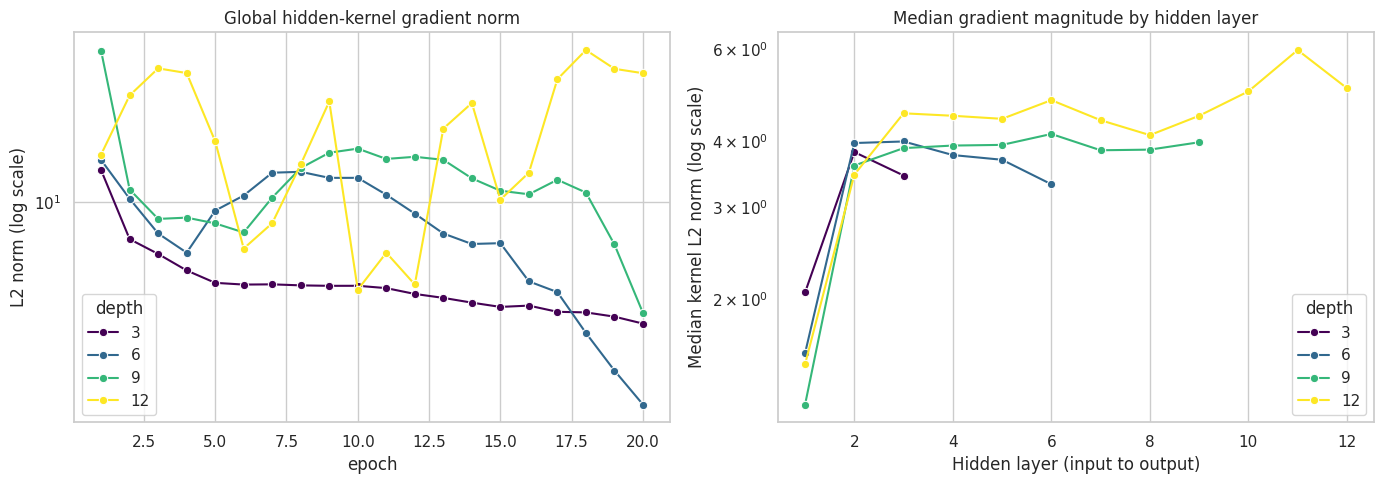

In [79]:
hidden_gradients = gradient_frame[gradient_frame["layer"].str.startswith("hidden_")].copy()
hidden_gradients["layer_index"] = hidden_gradients["layer"].str.extract(r"(\d+)").astype(int)

global_kernel_norm = (
    hidden_gradients.groupby(["depth", "epoch"])["l2_norm"]
    .apply(lambda values: np.sqrt(np.square(values).sum()))
    .rename("global_kernel_l2_norm")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=global_kernel_norm, x="epoch", y="global_kernel_l2_norm",
    hue="depth", palette="viridis", marker="o", ax=axes[0]
)
axes[0].set_yscale("log")
axes[0].set(title="Global hidden-kernel gradient norm", ylabel="L2 norm (log scale)")

median_layer_norm = (
    hidden_gradients.groupby(["depth", "layer_index"], as_index=False)["l2_norm"].median()
)
sns.lineplot(
    data=median_layer_norm, x="layer_index", y="l2_norm",
    hue="depth", palette="viridis", marker="o", ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set(
    title="Median gradient magnitude by hidden layer",
    xlabel="Hidden layer (input to output)", ylabel="Median kernel L2 norm (log scale)"
)
plt.tight_layout()
plt.show()


In [80]:
gradient_diagnostics = []
for depth, group in hidden_gradients.groupby("depth"):
    final_epoch = group[group["epoch"] == group["epoch"].max()].sort_values("layer_index")
    first_norm = final_epoch.iloc[0]["l2_norm"]
    last_norm = final_epoch.iloc[-1]["l2_norm"]
    positive_norms = final_epoch.loc[final_epoch["l2_norm"] > 0, "l2_norm"]
    gradient_diagnostics.append({
        "depth": depth,
        "first_hidden_norm": first_norm,
        "last_hidden_norm": last_norm,
        "log10_first_to_last_ratio": np.log10((first_norm + 1e-12) / (last_norm + 1e-12)),
        "max_to_min_ratio": positive_norms.max() / positive_norms.min(),
    })

gradient_diagnostics = pd.DataFrame(gradient_diagnostics)
gradient_diagnostics.style.format({
    "first_hidden_norm": "{:.3e}",
    "last_hidden_norm": "{:.3e}",
    "log10_first_to_last_ratio": "{:.2f}",
    "max_to_min_ratio": "{:.1f}",
})

,depth,first_hidden_norm,last_hidden_norm,log10_first_to_last_ratio,max_to_min_ratio
0,3,1.401e+00,3.027e+00,-0.33,2.2
1,6,6.609e-01,7.094e-01,-0.03,2.2
2,9,8.516e-01,1.383e+00,-0.21,2.5
3,12,2.135e+00,7.756e+00,-0.56,4.3


Based only on gradient flow:

Depth 6: most balanced gradients.
Depth 3: mild imbalance and simplest architecture.
Depth 9: moderate imbalance.
Depth 12: largest disparity, but no conclusive vanishing or explosion.

# Part 3: Advanced Optimization Techniques


### This section
1. Compares optimizers: SGD, Adam, RMSprop, AdaGrad.  
2. Tests weight initializations (Glorot/Xavier, He, etc.)  
3. Experiments with activations: ReLU, Leaky ReLU, ELU, Swish.  
4. Applies normalization layers.  
5. Evaluates learning rate schedules.  


In [82]:
from keras.initializers import HeNormal, HeUniform, GlorotUniform, GlorotNormal


In [83]:
current_config = {
    "depth": int(depth_results.sort_values(["val_mae", "val_loss"]).iloc[0]["depth"]),
    "units": 64,
    "activation": "relu",
    "initializer": "he_uniform",
    "optimizer": "adam",
    "batch_norm": False,
    "lr_schedule": False,
    "regularizer": None,
    "dropout": 0.0,
    "clipnorm": 1.0,
}
all_trials = {}

def run_trial(config, seed=SEED):
    tf.keras.backend.clear_session()
    set_all_seeds(seed)
    model2 = build_model(config, X_train_scaled_best.shape[1])
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=PATIENCE, restore_best_weights=True
    )
    history2 = model2.fit(
        X_train_scaled_best,
        y_train_array,
        validation_data=(X_val_scaled_best, y_val_array),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stopping],
        verbose=0,
        shuffle=True,
    )
    validation_loss, validation_mae = model2.evaluate(X_val_scaled_best, y_val_array, verbose=0)
    return {
        "config": deepcopy(config),
        "history": history.history,
        "epochs_ran": len(history.history["loss"]),
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
        "val_loss": float(validation_loss),
        "val_mae": float(validation_mae),
    }

def run_stage(stage_name, candidates):
    stage_trials = {}
    rows = []
    for label, updates in candidates.items():
        raw_name = f"{stage_name}_{label}".lower()
        safe_name = "".join(character if character.isalnum() else "_" for character in raw_name).strip("_")
        config = {**current_config, **updates, "name": safe_name}
        trial = run_trial(config)
        stage_trials[label] = trial
        rows.append({
            "candidate": label,
            "val_loss": trial["val_loss"],
            "val_mae": trial["val_mae"],
            "best_epoch": trial["best_epoch"],
            "epochs_ran": trial["epochs_ran"],
            "learning_rate": LEARNING_RATES[config["optimizer"]],
        })
    results = pd.DataFrame(rows).sort_values(["val_mae", "val_loss"]).reset_index(drop=True)
    winner = results.iloc[0]["candidate"]
    all_trials[stage_name] = stage_trials
    return winner, results

def show_stage(results, title):
    display(results.style.format({
        "val_loss": "{:.4f}", "val_mae": "{:.4f}", "learning_rate": "{:.4g}"
    }))
    plt.figure(figsize=(8, 3.8))
    sns.barplot(data=results, x="val_mae", y="candidate", color="#457b9d")
    plt.axvline(float(validation_baseline["MAE"]), color="#e76f51", linestyle="--", label="Mean baseline")
    plt.title(title)
    plt.xlabel("Validation MAE (lower is better)")
    plt.ylabel("")
    plt.legend()
    plt.tight_layout()
    plt.show()


,candidate,val_loss,val_mae,best_epoch,epochs_ran,learning_rate
0,Adagrad,0.5971,0.5993,15,20,0.01
1,SGD,0.5789,0.6056,15,20,0.01
2,Adam,0.7046,0.6568,15,20,0.001
3,RMSprop,1.7770,1.0625,15,20,0.001


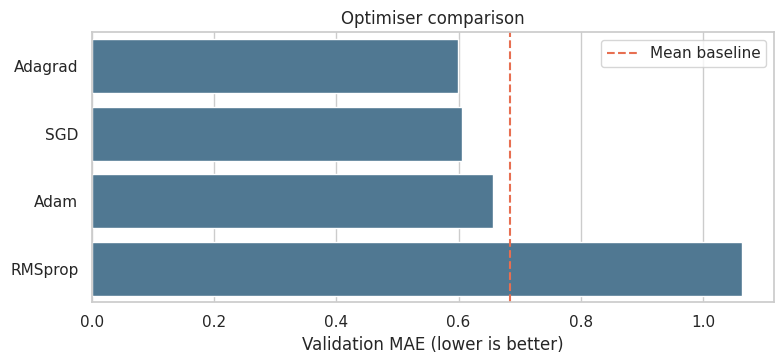

In [84]:
best_optimizer, optimizer_results = run_stage("optimizer", {
    "SGD": {"optimizer": "sgd"},
    "Adam": {"optimizer": "adam"},
    "RMSprop": {"optimizer": "rmsprop"},
    "Adagrad": {"optimizer": "adagrad"},
})
current_config["optimizer"] = all_trials["optimizer"][best_optimizer]["config"]["optimizer"]
show_stage(optimizer_results, "Optimiser comparison")


,candidate,val_loss,val_mae,best_epoch,epochs_ran,learning_rate
0,Glorot uniform,0.4698,0.5319,15,20,0.01
1,He uniform,0.5971,0.5993,15,20,0.01
2,He normal,0.7181,0.6452,15,20,0.01


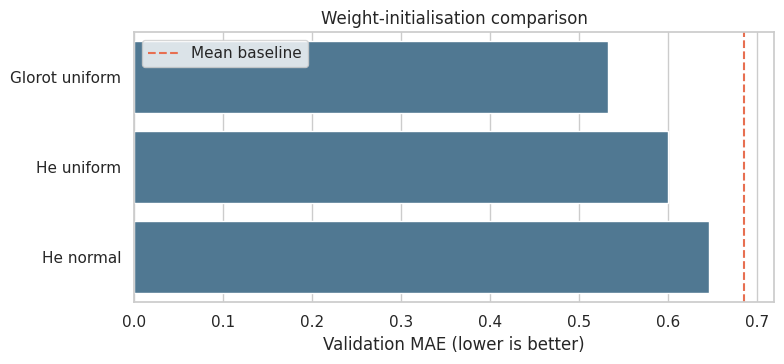

In [85]:
best_initializer, initializer_results = run_stage("initializer", {
    "Glorot uniform": {"initializer": "glorot_uniform"},
    "He uniform": {"initializer": "he_uniform"},
    "He normal": {"initializer": "he_normal"},
})
current_config["initializer"] = all_trials["initializer"][best_initializer]["config"]["initializer"]
show_stage(initializer_results, "Weight-initialisation comparison")


,candidate,val_loss,val_mae,best_epoch,epochs_ran,learning_rate
0,Swish,0.4104,0.5004,15,20,0.01
1,ELU,0.4149,0.5057,15,20,0.01
2,Leaky ReLU,0.4622,0.5237,15,20,0.01
3,ReLU,0.4698,0.5319,15,20,0.01


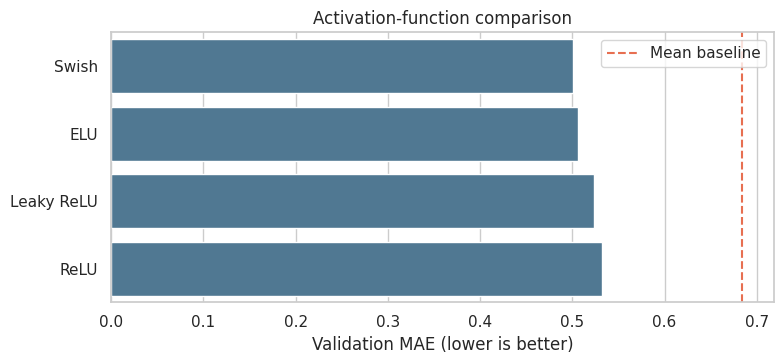

In [86]:
best_activation, activation_results = run_stage("activation", {
    "ReLU": {"activation": "relu"},
    "Leaky ReLU": {"activation": "leaky_relu"},
    "ELU": {"activation": "elu"},
    "Swish": {"activation": "swish"},
})
current_config["activation"] = all_trials["activation"][best_activation]["config"]["activation"]
show_stage(activation_results, "Activation-function comparison")


,candidate,val_loss,val_mae,best_epoch,epochs_ran,learning_rate
0,Decay; no batch norm,0.4077,0.4995,15,20,0.01
1,Fixed LR; no batch norm,0.4104,0.5004,15,20,0.01
2,Decay; batch norm,0.5208,0.5843,15,20,0.01
3,Fixed LR; batch norm,0.5316,0.5936,15,20,0.01


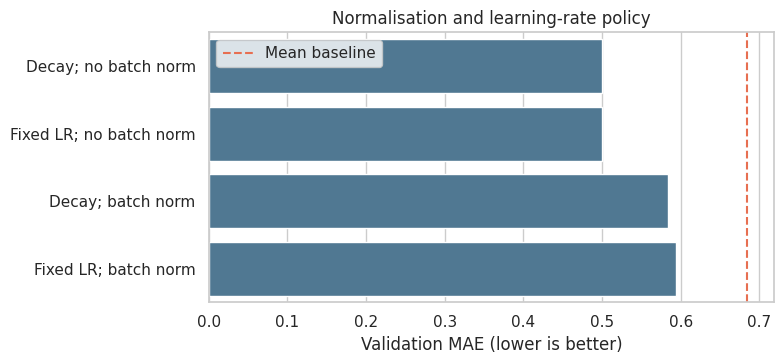

In [87]:
best_training_policy, training_policy_results = run_stage("training_policy", {
    "Fixed LR; no batch norm": {"batch_norm": False, "lr_schedule": False},
    "Fixed LR; batch norm": {"batch_norm": True, "lr_schedule": False},
    "Decay; no batch norm": {"batch_norm": False, "lr_schedule": True},
    "Decay; batch norm": {"batch_norm": True, "lr_schedule": True},
})
winning_policy = all_trials["training_policy"][best_training_policy]["config"]
current_config.update({
    "batch_norm": winning_policy["batch_norm"],
    "lr_schedule": winning_policy["lr_schedule"],
})
show_stage(training_policy_results, "Normalisation and learning-rate policy")

# Part 4: Regularization & Generalization

### This section:
1. Apply L1, L2, and Elastic Net.  
2. Implement dropout at different layers.  
3. Use early stopping with patience.  
4. Plot learning curves; analyze bias-variance.  


,candidate,val_loss,val_mae,best_epoch,epochs_ran,learning_rate
0,Dropout 0.20,0.4074,0.4972,15,20,0.01
1,L2 + dropout 0.20,0.4615,0.4972,15,20,0.01
2,Elastic Net,0.4987,0.4995,15,20,0.01
3,L1,0.4446,0.4995,15,20,0.01
4,L2,0.4620,0.4995,15,20,0.01
5,No regularisation,0.4077,0.4995,15,20,0.01


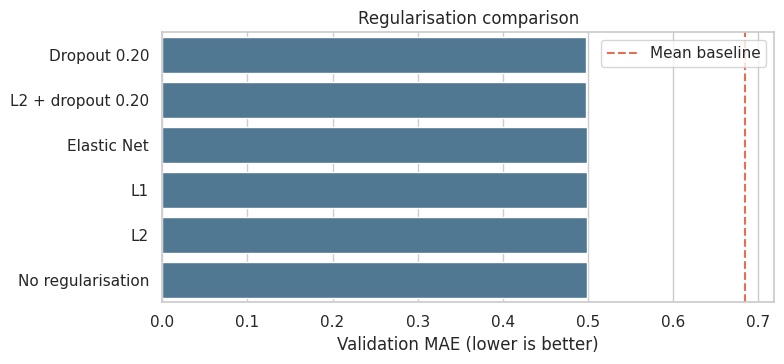

In [88]:
best_regularization, regularization_results = run_stage("regularization", {
    "No regularisation": {"regularizer": None, "dropout": 0.0},
    "L1": {"regularizer": "l1", "l1": 1e-5, "dropout": 0.0},
    "L2": {"regularizer": "l2", "l2": 1e-4, "dropout": 0.0},
    "Elastic Net": {"regularizer": "elastic_net", "l1": 1e-5, "l2": 1e-4, "dropout": 0.0},
    "Dropout 0.20": {"regularizer": None, "dropout": 0.20},
    "L2 + dropout 0.20": {"regularizer": "l2", "l2": 1e-4, "dropout": 0.20},
})
winning_regularization = all_trials["regularization"][best_regularization]["config"]
current_config.update({
    "regularizer": winning_regularization.get("regularizer"),
    "l1": winning_regularization.get("l1", 1e-5),
    "l2": winning_regularization.get("l2", 1e-4),
    "dropout": winning_regularization.get("dropout", 0.0),
})
show_stage(regularization_results, "Regularisation comparison")

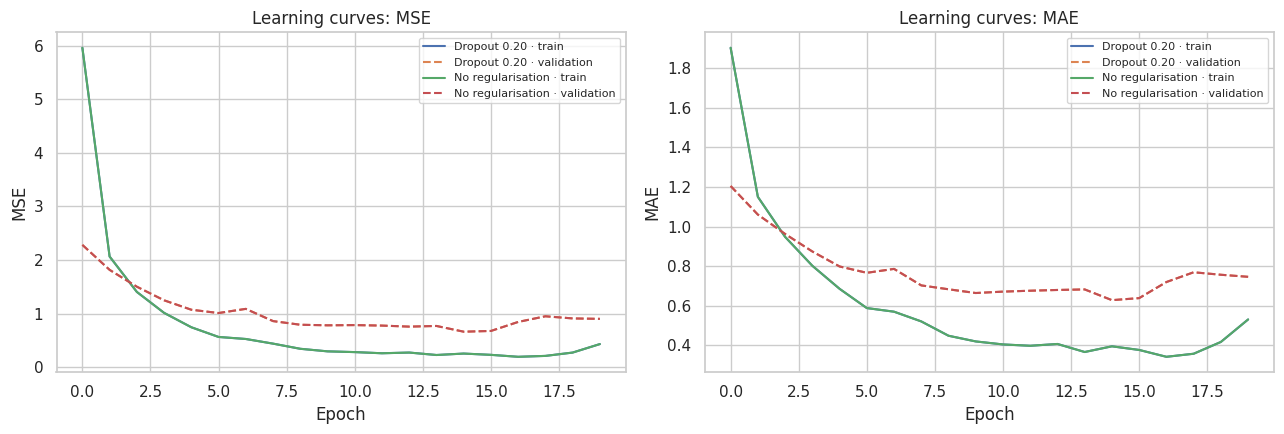

,train_loss_at_best_epoch,validation_loss_at_best_epoch,generalisation_gap
Dropout 0.20,0.2538,0.6618,0.4081


In [89]:
curve_labels = list(dict.fromkeys([best_regularization, "No regularisation"]))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label in curve_labels:
    history = all_trials["regularization"][label]["history"]
    axes[0].plot(history["loss"], label=f"{label} · train")
    axes[0].plot(history["val_loss"], linestyle="--", label=f"{label} · validation")
    axes[1].plot(history["mae"], label=f"{label} · train")
    axes[1].plot(history["val_mae"], linestyle="--", label=f"{label} · validation")

axes[0].set(title="Learning curves: MSE", xlabel="Epoch", ylabel="MSE")
axes[1].set(title="Learning curves: MAE", xlabel="Epoch", ylabel="MAE")
for axis in axes:
    axis.legend(fontsize=8)
plt.tight_layout()
plt.show()

selected_history = all_trials["regularization"][best_regularization]["history"]
selected_best_epoch = all_trials["regularization"][best_regularization]["best_epoch"] - 1
learning_curve_diagnostic = pd.Series({
    "train_loss_at_best_epoch": selected_history["loss"][selected_best_epoch],
    "validation_loss_at_best_epoch": selected_history["val_loss"][selected_best_epoch],
    "generalisation_gap": (
        selected_history["val_loss"][selected_best_epoch]
        - selected_history["loss"][selected_best_epoch]
    ),
}, name=best_regularization)
display(learning_curve_diagnostic.to_frame().T.style.format("{:.4f}"))

In [90]:
final_config = deepcopy(current_config)
selected_trial = all_trials["regularization"][best_regularization]
selected_epochs = selected_trial["best_epoch"]

X_development = pd.concat([X_train, X_val])
y_development = pd.concat([y_train, y_val])
final_selector = SelectKBest(score_func=f_regression, k=min(12, X_development.shape[1]))
X_development_selected = final_selector.fit_transform(X_development, y_development)
X_test_final_selected = final_selector.transform(X_test)
final_scaler = StandardScaler()
X_development_scaled = final_scaler.fit_transform(X_development_selected).astype("float32")
X_test_final_scaled = final_scaler.transform(X_test_final_selected).astype("float32")
y_development_array = y_development.to_numpy(dtype="float32").reshape(-1, 1)

tf.keras.backend.clear_session()
set_all_seeds(SEED)
final_model = build_model({**final_config, "name": "final_wine_quality_model"}, X_development_scaled.shape[1])
final_model.fit(
    X_development_scaled,
    y_development_array,
    epochs=selected_epochs,
    batch_size=BATCH_SIZE,
    verbose=0,
    shuffle=True,
)

test_predictions = final_model.predict(X_test_final_scaled, verbose=0).reshape(-1)
test_actual = y_test_array.reshape(-1)
baseline_predictions = np.full_like(test_actual, y_development_array.mean())

def regression_metrics(actual, prediction):
    return {
        "MAE": mean_absolute_error(actual, prediction),
        "RMSE": mean_squared_error(actual, prediction) ** 0.5,
        "R2": r2_score(actual, prediction),
        "within_one_point": np.mean(np.abs(actual - prediction) <= 1.0),
    }

final_metrics = regression_metrics(test_actual, test_predictions)
baseline_test_metrics = regression_metrics(test_actual, baseline_predictions)
test_comparison = pd.DataFrame(
    [baseline_test_metrics, final_metrics], index=["Mean baseline", "Selected neural network"]
)

rng = np.random.default_rng(SEED)
absolute_errors = np.abs(test_actual - test_predictions)
bootstrap_mae = np.array([
    rng.choice(absolute_errors, size=len(absolute_errors), replace=True).mean()
    for _ in range(2000)
])
mae_interval = np.quantile(bootstrap_mae, [0.025, 0.975])

display(test_comparison.style.format({
    "MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.3f}", "within_one_point": "{:.1%}"
}))
print(f"Selected test MAE 95% bootstrap interval: [{mae_interval[0]:.4f}, {mae_interval[1]:.4f}]")


,MAE,RMSE,R2,within_one_point
Mean baseline,0.6812,0.8033,-0.000,82.5%
Selected neural network,0.5044,0.6479,0.349,90.6%


Selected test MAE 95% bootstrap interval: [0.4595, 0.5500]


In [91]:
configuration_for_display = {
    key: final_config.get(key)
    for key in [
        "depth", "units", "activation", "initializer", "optimizer",
        "batch_norm", "lr_schedule", "regularizer", "dropout"
    ]
}

display(Markdown(f"""
### Executive result

The staged validation search selected `{json.dumps(configuration_for_display)}` and refitted it for **{selected_epochs} epochs** on the combined development data.

On the untouched test set, the selected network achieved:

- **MAE:** {final_metrics['MAE']:.3f} quality-score points (95% bootstrap interval {mae_interval[0]:.3f}–{mae_interval[1]:.3f});
- **RMSE:** {final_metrics['RMSE']:.3f};
- **R²:** {final_metrics['R2']:.3f};
- **Predictions within one quality point:** {final_metrics['within_one_point']:.1%}.

The mean baseline MAE was **{baseline_test_metrics['MAE']:.3f}**. These results describe this split and seed; repeated or nested cross-validation would be required before claiming that one optimiser or architecture is generally superior.
"""))



### Executive result

The staged validation search selected `{"depth": 9, "units": 64, "activation": "swish", "initializer": "glorot_uniform", "optimizer": "adagrad", "batch_norm": false, "lr_schedule": true, "regularizer": null, "dropout": 0.2}` and refitted it for **15 epochs** on the combined development data.

On the untouched test set, the selected network achieved:

- **MAE:** 0.504 quality-score points (95% bootstrap interval 0.459–0.550);
- **RMSE:** 0.648;
- **R²:** 0.349;
- **Predictions within one quality point:** 90.6%.

The mean baseline MAE was **0.681**. These results describe this split and seed; repeated or nested cross-validation would be required before claiming that one optimiser or architecture is generally superior.
